In [2]:
import pandas as pd
import numpy as np

In [3]:
df =pd.read_csv("Dataset-SA.csv")

In [5]:
df.shape

(205052, 6)

In [6]:
df.columns

Index(['product_name', 'product_price', 'Rate', 'Review', 'Summary',
       'Sentiment'],
      dtype='object')

In [7]:
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [8]:
df.isnull().sum()

product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64

In [9]:
df=df.drop_duplicates()

In [10]:
df = df.dropna(subset=["Review"])

In [11]:
df["text"] = df["Review"].fillna("") + " " + df["Summary"].fillna("")

In [12]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)

In [13]:
df["Rate"] = pd.to_numeric(df["Rate"], errors="coerce")

In [14]:
df["product_price"] = pd.to_numeric(
    df["product_price"], errors="coerce"
)

In [15]:
print(df["Sentiment"].value_counts())

Sentiment
positive    122813
negative     23353
neutral       8309
Name: count, dtype: int64


In [17]:
df.shape

(154475, 8)

In [18]:
df.isnull().sum()

product_name     0
product_price    3
Rate             3
Review           0
Summary          8
Sentiment        0
text             0
clean_text       0
dtype: int64

In [19]:
df = df.dropna(subset=["product_price", "Rate"])
df["Summary"] = df["Summary"].fillna("")

In [20]:
print(df.shape)
print(df.isnull().sum())

(154472, 8)
product_name     0
product_price    0
Rate             0
Review           0
Summary          0
Sentiment        0
text             0
clean_text       0
dtype: int64


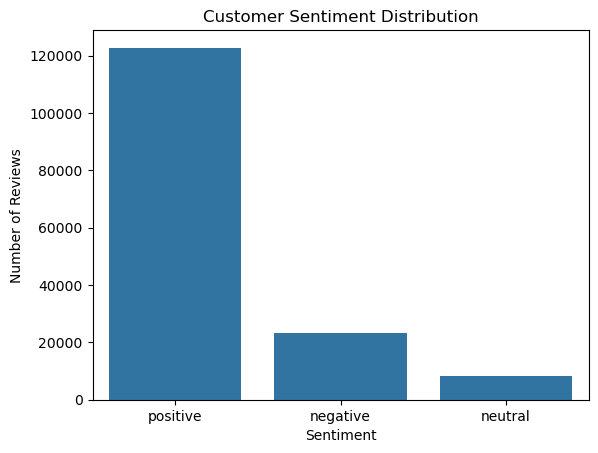

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Sentiment")
plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

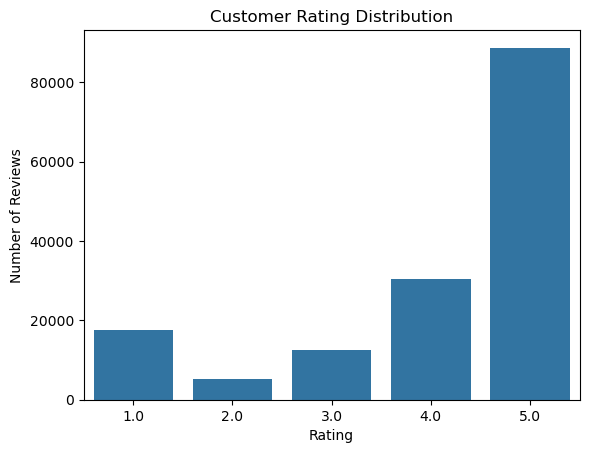

In [22]:
sns.countplot(data=df, x="Rate")
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

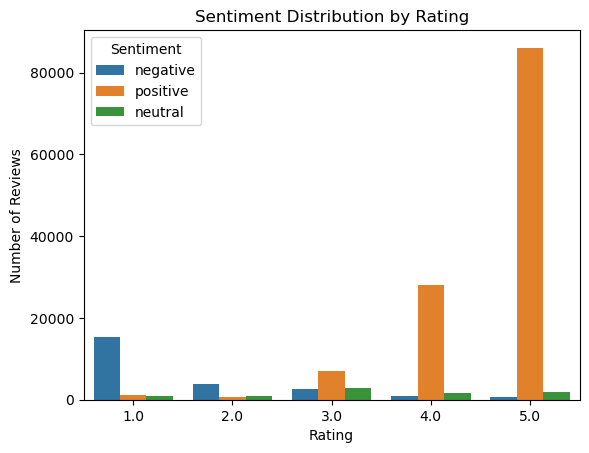

In [23]:
sns.countplot(data=df, x="Rate", hue="Sentiment")
plt.title("Sentiment Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

In [24]:
sentiment_percent = df["Sentiment"].value_counts(normalize=True) * 100

print(sentiment_percent.round(2))

Sentiment
positive    79.50
negative    15.12
neutral      5.38
Name: proportion, dtype: float64


In [25]:
top_products = df["product_name"].value_counts().head(10)

print(top_products)

product_name
cello Pack of 18 Opalware Cello Dazzle Lush Fiesta Opalware Dinner Set, 18 Pieces Dinner SetÃÂ ÃÂ (White, Microwave Safe)    4362
Lakm?? Eyeconic Kajal Twin Pack??????????(Deep Black, 0.7 g)                                                                   2805
Mi 5A 80 cm (32 inch) HD Ready LED Smart Android TV with Dolby Audio (2022 Model)                                              2122
Singer FM 1409 Electric Sewing MachineÐÒ?ÐÓ®ÐÂ ÐÒ?ÐÓ®ÐÂ ( Built-in Stitches 9)                                         1743
Canon EOS 3000D DSLR Camera 1 Camera Body, 18 - 55 mm Lens????????(Black)                                                      1646
cello Pack of 18 Opalware Cello Dazzle Lush Fiesta Opalware Dinner Set 18 Pieces Dinner SetWhite Microwave Safe                1642
NIVIA Storm Football - Size: 5ÐÓ®ÐÂ ÐÓ®ÐÂ (Pack of 1, Multicolor)                                                          1613
POCO C31 (Royal Blue, 64 GB)?ÐÒÐÒ?ÐÒÐÒ(4 GB RAM)       

In [26]:
print(df[["Review", "clean_text", "Sentiment"]].head(10))

               Review                                         clean_text  \
0              super!  super great cooler excellent air flow and for ...   
1             awesome        awesome best budget fit cooler nice cooling   
2                fair  fair the quality is good but the power of air ...   
3     useless product  useless product very bad product its a only a fan   
4                fair                                 fair ok ok product   
5             awesome  awesome the cooler is really fantastic and pro...   
6  highly recommended               highly recommended very good product   
7                nice                                     nice very nice   
8      unsatisfactory                     unsatisfactory very bad cooler   
9     worth the money                          worth the money very good   

  Sentiment  
0  positive  
1  positive  
2  positive  
3  negative  
4   neutral  
5  positive  
6  positive  
7  positive  
8  negative  
9  positive  


In [27]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [28]:
stop_words = set(stopwords.words("english"))

In [29]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

In [30]:
X = df["clean_text"]
y = df["Sentiment"]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [33]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(123577, 10000)
(30895, 10000)


In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [35]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

['positive' 'negative' 'positive' 'negative' 'positive' 'negative'
 'negative' 'positive' 'positive' 'positive']


In [36]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9264929600258942


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.85      0.84      0.85      4670
     neutral       0.70      0.36      0.48      1662
    positive       0.95      0.98      0.96     24563

    accuracy                           0.93     30895
   macro avg       0.84      0.73      0.76     30895
weighted avg       0.92      0.93      0.92     30895



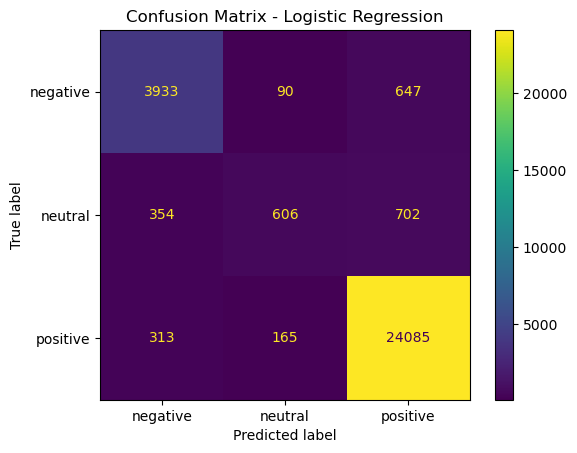

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [39]:
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_model.fit(X_train_tfidf, y_train)

y_pred_balanced = balanced_model.predict(X_test_tfidf)

In [40]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

    negative       0.80      0.84      0.82      4670
     neutral       0.32      0.66      0.43      1662
    positive       0.98      0.90      0.94     24563

    accuracy                           0.88     30895
   macro avg       0.70      0.80      0.73     30895
weighted avg       0.92      0.88      0.89     30895



In [41]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

    negative       0.85      0.84      0.84      4670
     neutral       0.68      0.37      0.48      1662
    positive       0.95      0.98      0.96     24563

    accuracy                           0.93     30895
   macro avg       0.82      0.73      0.76     30895
weighted avg       0.92      0.93      0.92     30895



In [44]:
from sklearn.metrics import accuracy_score

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.9251335167502832


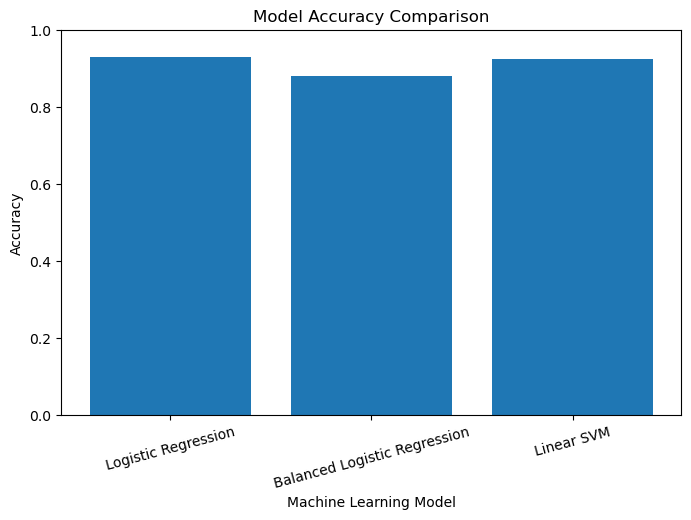

In [45]:
models = ["Logistic Regression", "Balanced Logistic Regression", "Linear SVM"]
accuracy = [0.93, 0.88, 0.9251]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

In [46]:
comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy
})

print(comparison)

                          Model  Accuracy
0           Logistic Regression    0.9300
1  Balanced Logistic Regression    0.8800
2                    Linear SVM    0.9251


In [47]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [48]:
review = ["The product quality is excellent and I am very happy with it"]

review_tfidf = tfidf.transform(review)

prediction = model.predict(review_tfidf)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: positive


In [49]:
review = ["Very poor quality, the product stopped working after one day"]

review_tfidf = tfidf.transform(review)

prediction = model.predict(review_tfidf)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: negative


In [50]:
review = ["The product is okay, nothing special"]

review_tfidf = tfidf.transform(review)

prediction = model.predict(review_tfidf)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: negative


In [51]:
review = ["The product is okay, nothing special"]

review_tfidf = tfidf.transform(review)

prediction = model.predict(review_tfidf)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: negative


In [52]:
review = ["The product is okay, nothing special"]

cleaned_review = [clean_text(review[0])]

review_tfidf = tfidf.transform(cleaned_review)

prediction = model.predict(review_tfidf)

print("Cleaned Review:", cleaned_review[0])
print("Predicted Sentiment:", prediction[0])

Cleaned Review: product okay nothing special
Predicted Sentiment: negative


In [53]:
review = ["The product is average and it works as expected"]

cleaned_review = [clean_text(review[0])]

review_tfidf = tfidf.transform(cleaned_review)

prediction = model.predict(review_tfidf)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: neutral


In [54]:
def predict_sentiment(review):
    cleaned = clean_text(review)
    vector = tfidf.transform([cleaned])
    return model.predict(vector)[0]

In [55]:
print(predict_sentiment("The product quality is excellent"))
print(predict_sentiment("Very poor quality and stopped working"))
print(predict_sentiment("The product is average and works as expected"))

positive
negative
neutral


In [57]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.
